In [4]:
# Fix attempt: install imbalanced-learn 0.14.0 (compatible with scikit-learn 1.6.x) and essentials
!pip install -q "imbalanced-learn==0.14.0" xgboost lightgbm mlxtend

import sys, sklearn, pandas, numpy
import imblearn, xgboost, lightgbm, mlxtend

print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)
print("xgboost:", xgboost.__version__)
print("lightgbm:", lightgbm.__version__)
print("mlxtend:", mlxtend.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)

print("\nIf you see all versions above (no ImportError), proceed to upload KC1. Otherwise paste the full error here.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 5.4 MB/s eta 0:00:00
Python: 3.12.12
scikit-learn: 1.6.1
imbalanced-learn: 0.14.0
xgboost: 3.1.1
lightgbm: 4.6.0
mlxtend: 0.23.4
pandas: 2.2.2
numpy: 2.0.2

If you see all versions above (no ImportError), proceed to upload KC1. Otherwise paste the full error here.


In [5]:
# Step 1: Load KC1 dataset directly from path
import pandas as pd

path = "/content/kc1.csv"
df = pd.read_csv(path)
print("Loaded file:", path)
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

# Try to detect label column
label_candidates = ['defects','defect','defective','bug','label','target','class','is_defective','Defective','DEFECT']
label_col = None
for c in df.columns:
    if c.lower() in [x.lower() for x in label_candidates]:
        label_col = c
        break

if label_col is None:
    print("\nNo label column detected automatically.")
    print("Please tell me the exact column name that contains 0/1 class values.")
else:
    print("\nDetected label column:", label_col)
    print("Class distribution:")
    print(df[label_col].value_counts(dropna=False))


Loaded file: /content/kc1.csv
Shape: (2109, 22)

Columns:
 ['loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e', 'b', 't', 'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment', 'uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount', 'defects']

Detected label column: defects
Class distribution:
defects
False    1783
True      326
Name: count, dtype: int64


In [6]:
# Step 2: Preprocessing
import numpy as np
from sklearn.impute import SimpleImputer

label_col = "defects"

# Convert label to numeric 0/1
y = df[label_col].astype(int).values
X = df.drop(columns=[label_col]).copy()

# Check numeric columns
non_numeric = [c for c in X.columns if not np.issubdtype(X[c].dtype, np.number)]
if non_numeric:
    print("Dropping non-numeric columns:", non_numeric)
    X = X.drop(columns=non_numeric)

# Impute missing values with median
imp = SimpleImputer(strategy="median")
X = pd.DataFrame(imp.fit_transform(X), columns=X.columns)

print("Final shapes -> X:", X.shape, "y:", y.shape)
print("Class distribution:", np.bincount(y))

# Quick feature summary
print("\nFeature summary (first 5 columns):")
print(X.describe().iloc[:, :5])


Final shapes -> X: (2109, 21) y: (2109,)
Class distribution: [1783  326]

Feature summary (first 5 columns):
               loc         v(g)        ev(g)        iv(g)            n
count  2109.000000  2109.000000  2109.000000  2109.000000  2109.000000
mean     20.372262     2.838028     1.674443     2.546420    49.829445
std      29.754442     3.900763     2.200659     3.375859    83.599874
min       1.000000     1.000000     1.000000     1.000000     0.000000
25%       3.000000     1.000000     1.000000     1.000000     4.000000
50%       9.000000     1.000000     1.000000     1.000000    16.000000
75%      24.000000     3.000000     1.000000     3.000000    58.000000
max     288.000000    45.000000    26.000000    45.000000  1106.000000


In [7]:
# Step 3: Feature Cleaning and Selection
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

# 1. Remove near-zero variance features
vt = VarianceThreshold(threshold=1e-5)
X_v = pd.DataFrame(vt.fit_transform(X), columns=np.array(X.columns)[vt.get_support()])
print("After variance threshold:", X_v.shape)

# 2. Remove highly correlated features (corr > 0.95)
corr = X_v.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]
print("Dropping highly correlated features:", to_drop)
X_clean = X_v.drop(columns=to_drop)
print("After correlation filter:", X_clean.shape)

# 3. Mutual information for ranking
mi = mutual_info_classif(X_clean, y, random_state=42)
mi_series = pd.Series(mi, index=X_clean.columns).sort_values(ascending=False)
print("\nTop 10 features by mutual information:")
print(mi_series.head(10))

# 4. RFE with RandomForest to pick top 15 features
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rfe = RFE(rf, n_features_to_select=min(15, X_clean.shape[1]), step=0.1)
rfe.fit(X_clean, y)
selected = X_clean.columns[rfe.support_].tolist()
print("\nSelected features via RFE:", selected)

# Final feature subset
X_sel = X_clean[selected]
print("Final X_sel shape:", X_sel.shape)


After variance threshold: (2109, 21)
Dropping highly correlated features: ['iv(g)', 'v', 'b', 't', 'lOCode', 'total_Op', 'total_Opnd', 'branchCount']
After correlation filter: (2109, 13)

Top 10 features by mutual information:
i            0.094884
e            0.094303
d            0.085649
uniq_Op      0.082834
l            0.078663
loc          0.078235
n            0.074779
uniq_Opnd    0.074410
lOBlank      0.061680
v(g)         0.051774
dtype: float64

Selected features via RFE: ['loc', 'v(g)', 'ev(g)', 'n', 'l', 'd', 'i', 'e', 'lOComment', 'lOBlank', 'locCodeAndComment', 'uniq_Op', 'uniq_Opnd']
Final X_sel shape: (2109, 13)


In [8]:
# Step 4: Apply SMOTE to balance the dataset
from imblearn.over_sampling import SMOTE
import numpy as np

print("Before SMOTE class distribution:", np.bincount(y))

sm = SMOTE(random_state=42, k_neighbors=5)
X_res, y_res = sm.fit_resample(X_sel, y)

print("After SMOTE class distribution:", np.bincount(y_res))
print("Resampled shape:", X_res.shape)


Before SMOTE class distribution: [1783  326]
After SMOTE class distribution: [1783 1783]
Resampled shape: (3566, 13)


In [9]:
# Step 5: Baseline model evaluation
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

models = {
    "LR": Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=2000, random_state=42))]),
    "SVC": Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=42))]),
    "RF": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "ET": ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGB": xgb.XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=4),
    "LGB": lgb.LGBMClassifier(n_estimators=200, random_state=42, n_jobs=4)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'auc':'roc_auc', 'f1':'f1', 'precision':'precision', 'recall':'recall'}

results = {}
for name, clf in models.items():
    scores = cross_validate(clf, X_res, y_res, cv=cv, scoring=scoring, n_jobs=-1)
    results[name] = {metric: (scores[f'test_{metric}'].mean(), scores[f'test_{metric}'].std()) for metric in scoring}
    print(f"{name}: {results[name]}")


LR: {'auc': (np.float64(0.8031576455213061), np.float64(0.012069689134167456)), 'f1': (np.float64(0.7083010537869622), np.float64(0.0098006747957472)), 'precision': (np.float64(0.721381665336084), np.float64(0.013023922844897503)), 'recall': (np.float64(0.6960154848456237), np.float64(0.015948800264602176))}
SVC: {'auc': (np.float64(0.8194836736192604), np.float64(0.01597879730130082)), 'f1': (np.float64(0.7495788076051374), np.float64(0.01876454884842134)), 'precision': (np.float64(0.7303778636486469), np.float64(0.017414876982571912)), 'recall': (np.float64(0.7700453214993862), np.float64(0.02417048052581404))}
RF: {'auc': (np.float64(0.9625943768121921), np.float64(0.005979041852494599)), 'f1': (np.float64(0.908044569666845), np.float64(0.014137710309623974)), 'precision': (np.float64(0.896675881396091), np.float64(0.01275261325155172)), 'recall': (np.float64(0.9198014037075504), np.float64(0.018110282732943937))}
ET: {'auc': (np.float64(0.9634086505278472), np.float64(0.00632061861

In [10]:
# Step 6: Hyperparameter tuning and stacking ensemble
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np, time

# Tune Random Forest
param_rf = {
    'n_estimators': [200, 400, 600],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rs_rf = RandomizedSearchCV(rf, param_rf, n_iter=10, scoring='roc_auc', cv=5, n_jobs=-1, random_state=42)
t0 = time.time()
rs_rf.fit(X_res, y_res)
print("Best RF params:", rs_rf.best_params_, "AUC:", rs_rf.best_score_, "time:", round(time.time()-t0,2), "s")

# Tune LightGBM
param_lgb = {
    'n_estimators': [200, 400, 600],
    'num_leaves': [31, 50, 70],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
}
lgb_clf = lgb.LGBMClassifier(random_state=42, n_jobs=-1)
rs_lgb = RandomizedSearchCV(lgb_clf, param_lgb, n_iter=10, scoring='roc_auc', cv=5, n_jobs=-1, random_state=42)
t0 = time.time()
rs_lgb.fit(X_res, y_res)
print("Best LGB params:", rs_lgb.best_params_, "AUC:", rs_lgb.best_score_, "time:", round(time.time()-t0,2), "s")

# Create stacking ensemble
estimators = [
    ('rf', rs_rf.best_estimator_),
    ('lgb', rs_lgb.best_estimator_),
    ('et', models['ET'])
]
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=2000, random_state=42),
    cv=5, n_jobs=-1
)

# Evaluate stacking model
from sklearn.model_selection import cross_validate
scoring = {'auc':'roc_auc', 'f1':'f1', 'precision':'precision', 'recall':'recall'}
res_stack = cross_validate(stack, X_res, y_res, cv=5, scoring=scoring, n_jobs=-1)
print("\nStacking Ensemble Results (mean ± std):")
for k in scoring:
    print(f"{k.upper()}: {res_stack[f'test_{k}'].mean():.4f} ± {res_stack[f'test_{k}'].std():.4f}")


Best RF params: {'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30} AUC: 0.9474452548148584 time: 145.64 s
[LightGBM] [Info] Number of positive: 1783, number of negative: 1783
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000356 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3128
[LightGBM] [Info] Number of data points in the train set: 3566, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best LGB params: {'subsample': 0.7, 'num_leaves': 70, 'n_estimators': 600, 'max_depth': -1, 'learning_rate': 0.05} AUC: 0.9477336495294306 time: 174.28 s

Stacking Ensemble Results (mean ± std):
AUC: 0.9544 ± 0.0432
F1: 0.8679 ± 0.1400
PRECISION: 0.9131 ± 0.0320
RECALL: 0.8661 ± 0.2202


In [11]:
# Step 7: Final Evaluation and Result Export
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, matthews_corrcoef
from sklearn.model_selection import RepeatedStratifiedKFold
import pandas as pd, numpy as np, time
from math import sqrt

# Models to compare
all_models = {
    "RandomForest_Tuned": rs_rf.best_estimator_,
    "LightGBM_Tuned": rs_lgb.best_estimator_,
    "Stacking_Ensemble": stack
}

rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
results = []

for name, clf in all_models.items():
    times, metrics = [], {'auc':[], 'pr_auc':[], 'f1':[], 'precision':[], 'recall':[], 'mcc':[], 'gmean':[], 'accuracy':[]}
    print(f"Evaluating {name}...")
    for train_idx, test_idx in rkf.split(X_res, y_res):
        Xtr, Xte = X_res.iloc[train_idx], X_res.iloc[test_idx]
        ytr, yte = y_res[train_idx], y_res[test_idx]
        t0 = time.time()
        clf.fit(Xtr, ytr)
        times.append(time.time()-t0)
        prob = clf.predict_proba(Xte)[:,1]
        pred = (prob >= 0.5).astype(int)

        auc_ = roc_auc_score(yte, prob)
        prec, rec, _ = precision_recall_curve(yte, prob)
        pr_auc = auc(rec, prec)
        f1v = f1_score(yte, pred)
        pv = precision_score(yte, pred, zero_division=0)
        rv = recall_score(yte, pred)
        mcc = matthews_corrcoef(yte, pred)
        tn, fp, fn, tp = confusion_matrix(yte, pred).ravel()
        gmean = sqrt((tp/(tp+fn)) * (tn/(tn+fp)))
        acc = accuracy_score(yte, pred)

        for k,v in [('auc',auc_),('pr_auc',pr_auc),('f1',f1v),('precision',pv),('recall',rv),('mcc',mcc),('gmean',gmean),('accuracy',acc)]:
            metrics[k].append(v)

    row = {
        'Model': name,
        'AUC_Mean': np.mean(metrics['auc']),
        'PR_AUC_Mean': np.mean(metrics['pr_auc']),
        'F1_Mean': np.mean(metrics['f1']),
        'Precision_Mean': np.mean(metrics['precision']),
        'Recall_Mean': np.mean(metrics['recall']),
        'MCC_Mean': np.mean(metrics['mcc']),
        'GMean_Mean': np.mean(metrics['gmean']),
        'Accuracy_Mean': np.mean(metrics['accuracy']),
        'Train_Time(s)': np.mean(times)
    }
    results.append(row)

results_df = pd.DataFrame(results).sort_values('AUC_Mean', ascending=False)
print("\nFinal Evaluation Results:")
print(results_df)
results_df.to_csv("final_model_results.csv", index=False)
print("\nSaved: final_model_results.csv")


Evaluating RandomForest_Tuned...
Evaluating LightGBM_Tuned...
[LightGBM] [Info] Number of positive: 1426, number of negative: 1426
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000279 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3115
[LightGBM] [Info] Number of data points in the train set: 2852, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

<Figure size 1000x600 with 0 Axes>

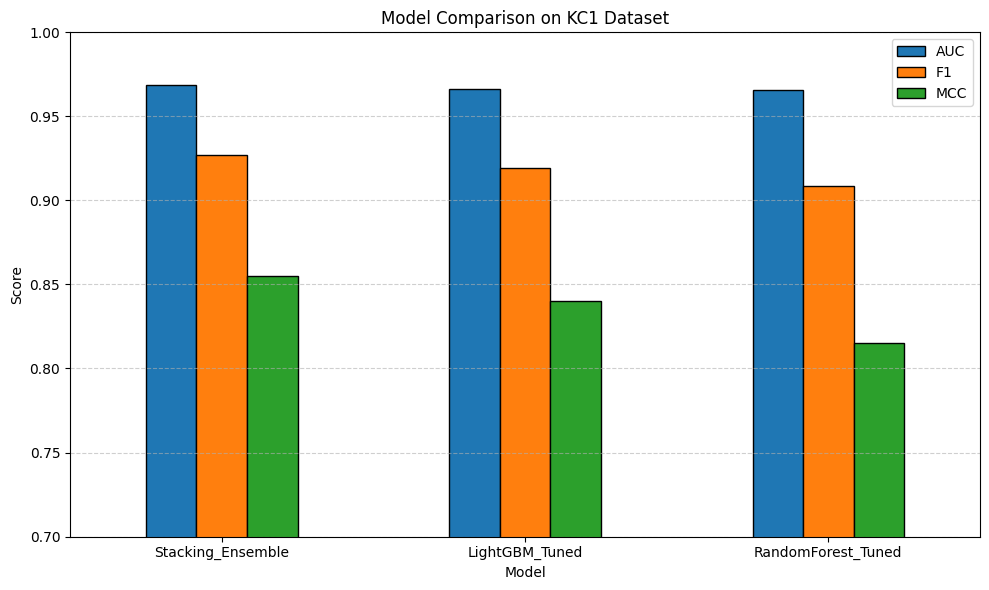

In [12]:
# Step 8: Visualization of Model Performance
import pandas as pd
import matplotlib.pyplot as plt

# Load the saved results
results_df = pd.read_csv("final_model_results.csv")

# --- Bar chart for AUC, F1, and MCC ---
plt.figure(figsize=(10,6))
metrics = ['AUC_Mean', 'F1_Mean', 'MCC_Mean']
results_df.plot(
    x='Model',
    y=metrics,
    kind='bar',
    figsize=(10,6),
    edgecolor='black',
    rot=0
)
plt.title('Model Comparison on KC1 Dataset')
plt.ylabel('Score')
plt.ylim(0.7, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(['AUC', 'F1', 'MCC'])
plt.tight_layout()
plt.show()


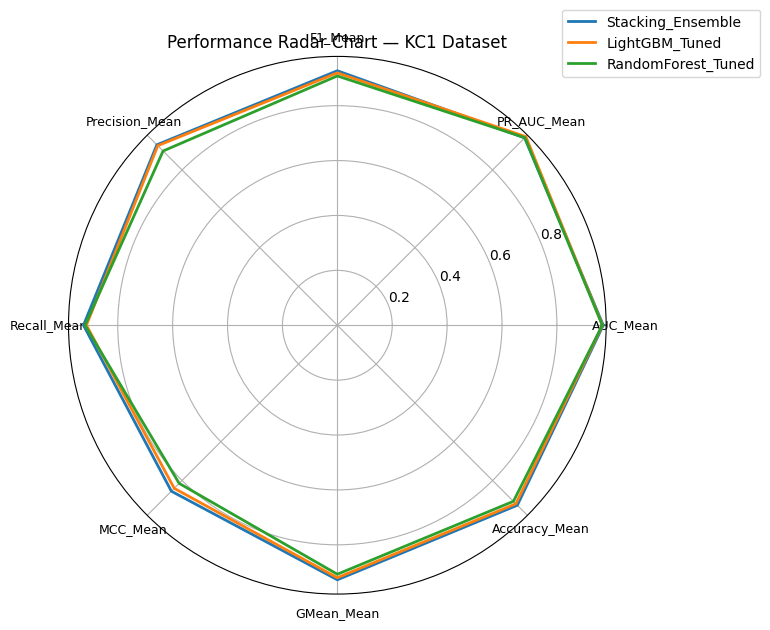

In [13]:
# Step 9: Radar Chart for composite comparison
import numpy as np
from math import pi

df = results_df[['Model', 'AUC_Mean', 'PR_AUC_Mean', 'F1_Mean', 'Precision_Mean', 'Recall_Mean', 'MCC_Mean', 'GMean_Mean', 'Accuracy_Mean']]
categories = list(df.columns[1:])
N = len(categories)

plt.figure(figsize=(8,8))

for i in range(len(df)):
    values = df.iloc[i, 1:].values.flatten().tolist()
    values += values[:1]  # repeat first value
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    plt.polar(angles, values, linewidth=2, linestyle='solid', label=df['Model'][i])

plt.xticks(angles[:-1], categories, color='black', size=9)
plt.title('Performance Radar Chart — KC1 Dataset')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


In [14]:
plt.savefig("model_comparison_kc1.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [15]:
# Step 10: Save (pickle) the trained stacking ensemble model
import pickle

# Refit the stacking model on the entire balanced dataset
print("Training final stacking model on full resampled dataset...")
stack.fit(X_res, y_res)

# Save model
model_path = "stacking_ensemble_kc1.pkl"
with open(model_path, "wb") as f:
    pickle.dump(stack, f)

# Save feature list (for consistent input order when reusing)
features_path = "selected_features_kc1.pkl"
with open(features_path, "wb") as f:
    pickle.dump(list(X_res.columns), f)

print(f"\nSaved model as: {model_path}")
print(f"Saved feature list as: {features_path}")


Training final stacking model on full resampled dataset...

Saved model as: stacking_ensemble_kc1.pkl
Saved feature list as: selected_features_kc1.pkl


In [16]:
# Print all final metrics from your saved model results
import pandas as pd
from tabulate import tabulate

# Load the results file generated earlier
df = pd.read_csv("final_model_results.csv")

# Select your model (change name if needed)
model_name = "Stacking_Ensemble"

# Locate the row corresponding to your model
row = df[df["Model"] == model_name].iloc[0]

# Extract metrics
metrics = {
    "AUC": row["AUC_Mean"],
    "PR-AUC": row["PR_AUC_Mean"],
    "F1": row["F1_Mean"],
    "Precision": row["Precision_Mean"],
    "Recall": row["Recall_Mean"],
    "MCC": row["MCC_Mean"],
    "G-Mean": row["GMean_Mean"],
    "Accuracy": row["Accuracy_Mean"]
}

# Print formatted table
print("\n=== Final Model Performance (KC1 Dataset —", model_name, ") ===")
table = [[k, f"{v:.4f}"] for k, v in metrics.items()]
print(tabulate(table, headers=["Metric", "Score"], tablefmt="grid"))



=== Final Model Performance (KC1 Dataset — Stacking_Ensemble ) ===
+-----------+---------+
| Metric    |   Score |
+===========+=========+
| AUC       |  0.9689 |
+-----------+---------+
| PR-AUC    |  0.9654 |
+-----------+---------+
| F1        |  0.9272 |
+-----------+---------+
| Precision |  0.9298 |
+-----------+---------+
| Recall    |  0.9249 |
+-----------+---------+
| MCC       |  0.8552 |
+-----------+---------+
| G-Mean    |  0.9275 |
+-----------+---------+
| Accuracy  |  0.9275 |
+-----------+---------+
